# 상관 분석
- 금, 은, 달러의 상관성 분석

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("datas2/일별_금은달러.xlsx")
df.head()

,일자,금값,은값,달러 환율
0,2020.08.07,78538.90,27.53,1188.5
1,2020.08.06,78009.22,28.39,1185.5
2,2020.08.05,77748.00,26.88,1188.0
3,2020.08.04,75873.57,26.01,1194.5
4,2020.08.03,75761.76,24.39,1195.7


In [3]:
df.sort_values(by = '일자', inplace = True)
df.head()

,일자,금값,은값,달러 환율
27,2020.06.30,68559.78,18.54,1203.0
26,2020.07.01,68941.28,18.13,1203.5
25,2020.07.02,68278.07,18.24,1199.0
24,2020.07.06,68269.27,18.50,1194.0
23,2020.07.07,68443.14,18.63,1197.0


In [4]:
# 그래프 기본 설정
from matplotlib import pyplot as plt
import numpy as np

# plt.rcParams["font.family"] = 'Malgun Gothic'  # 윈도우 환경
plt.rcParams["font.family"] = 'NanumGothic'      # WSL ubuntu 환경
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams["font.size"] = 20
plt.rcParams["figure.figsize"] = (10, 8)

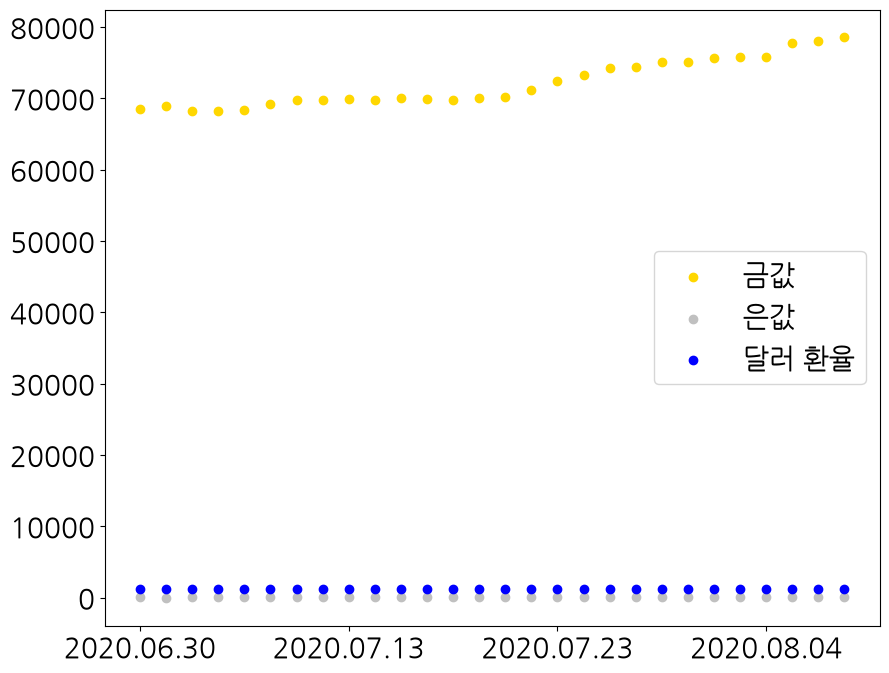

In [5]:
plt.scatter(df['일자'], df['금값'], label = '금값', color = 'gold')
plt.scatter(df['일자'], df['은값'], label = '은값', color = 'silver')
plt.scatter(df['일자'], df['달러 환율'], label = '달러 환율', color = 'blue')
plt.xticks(df['일자'].iloc[::8])
plt.legend()
plt.show()

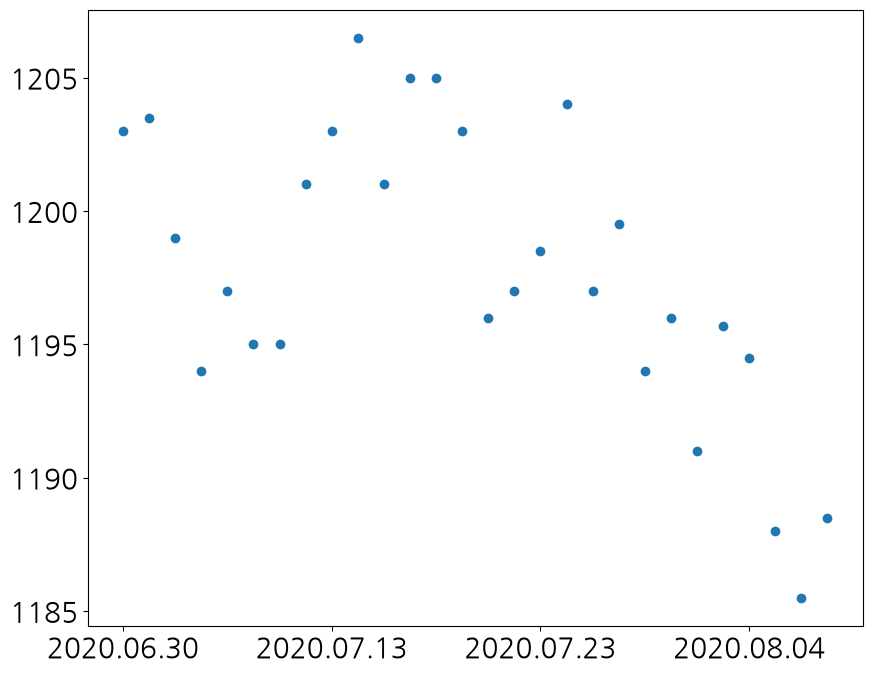

In [7]:
# plt.scatter(df['일자'], df['금값'])
# plt.scatter(df['일자'], df['은값'])
plt.scatter(df['일자'], df['달러 환율'])
plt.xticks(df['일자'].iloc[::8])
plt.show()

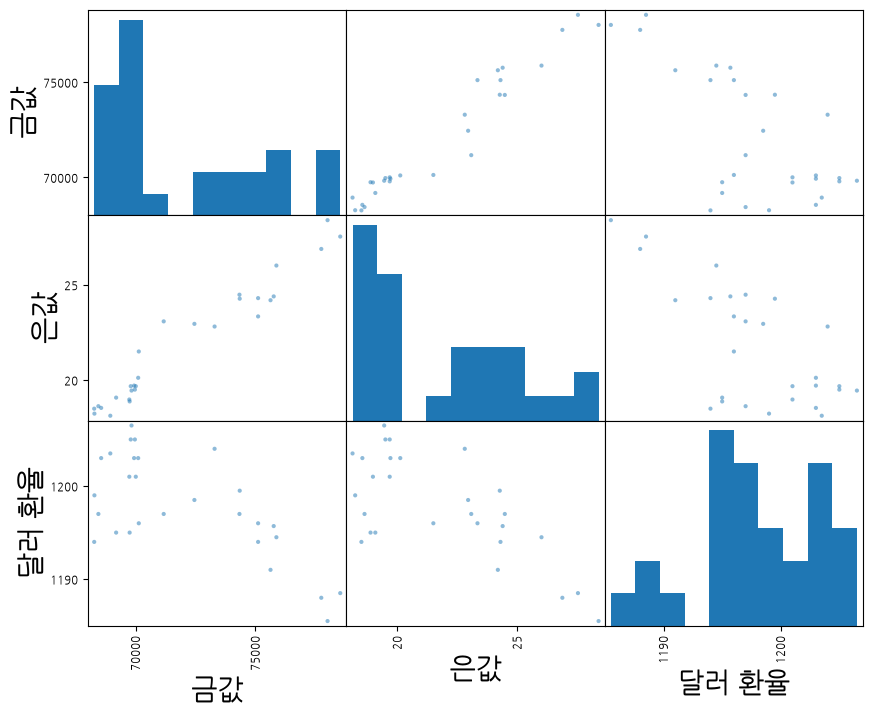

In [8]:
# scatter matrix

pd.plotting.scatter_matrix(df.drop('일자', axis=1))
plt.show()

# 피어슨 상관계수

In [12]:
from scipy import stats
print(stats.pearsonr(df['금값'],df['은값']))
print(stats.pearsonr(df['금값'],df['달러 환율']))
print(stats.pearsonr(df['은값'],df['달러 환율']))

PearsonRResult(statistic=np.float64(0.9718640116033498), pvalue=np.float64(7.508878356556179e-18))
PearsonRResult(statistic=np.float64(-0.6793266264341937), pvalue=np.float64(7.03332525845226e-05))
PearsonRResult(statistic=np.float64(-0.6954569556203563), pvalue=np.float64(3.989042061957927e-05))


[해석]
- 금값, 은값: 강력한 양의 상관관계
- 금값, 달러: 음의 상관관계
- 은값, 달러: 음의 상관관계

In [10]:
import itertools
target_columns = ['금값', '은값', '달러 환율']
for col1, col2 in itertools.combinations(target_columns, 2):
    result = stats.pearsonr(df[col1], df[col2])
    print("{} ~ {}: coef:{}, p-value: {}".format(col1, col2, result[0], result[1]))

금값 ~ 은값: coef:0.9718640116033498, p-value: 7.508878356556179e-18
금값 ~ 달러 환율: coef:-0.6793266264341937, p-value: 7.03332525845226e-05
은값 ~ 달러 환율: coef:-0.6954569556203563, p-value: 3.989042061957927e-05


# 스피어만 상관계수

In [14]:
import itertools
target_columns = ['금값', '은값', '달러 환율']

for col1, col2 in itertools.combinations(target_columns, 2):
    result = stats.spearmanr(df[col1], df[col2])
    print("{} ~ {}: coef:{}, p-value: {}".format(col1, col2, result[0], result[1]))

금값 ~ 은값: coef:0.9711235892228813, p-value: 1.0481280432981477e-17
금값 ~ 달러 환율: coef:-0.5039075855936102, p-value: 0.006257468267109452
은값 ~ 달러 환율: coef:-0.528106006718531, p-value: 0.003869997604824082


- 피어슨 : 값 자체의 직선관계
- 스피어만 : 순위의 증가.감소 관계
- 실무에서는 먼저 산점도를 보고, 선형관계이면 Pearson, 비선형이지만 일정한 증가·감소 관계이거나 순위형 데이터이면 Spearman을 선택하는 것이 좋음